###### 131_1_practical_mask_recurrence_graph_answer

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [5]:
#cell3
df_defect = pd.DataFrame(
    [
        ["2026-06-01", "SUS", "J69P", "D-001", "コイル", 1, 120000, "2026/06/01にKLAK-67890で1件発生。160V条件で確認。"],
        ["2026-06-03", "SUS", "J69P", "D-002", "コイル", 1, 120000, "2026/06/03にKLAK-67890で1件再発。160V条件で確認。"],
        ["2026-06-05", "SUS", "J69P", "D-003", "Buck-IC", 1, 120000, "2026/06/05にKLBC-12345で1件発生。12V条件で確認。"],
        ["2026-06-07", "SUS", "J69P", "D-004", "コイル", 1, 120000, "2026/06/07にKLAK-67890で1件再発。160V条件で確認。"],
        ["2026-06-02", "WSE", "310D", "D-005", "コイル", 2, 90000, "2026/06/02にLCM-220で2件発生。140V検査では検出せず。"],
        ["2026-06-04", "WSE", "310D", "D-006", "コイル", 1, 90000, "2026/06/04にLCM-220で1件再発。160V条件で確認。"],
        ["2026-06-06", "WSE", "310D", "D-007", "CAN通信", 1, 90000, "2026/06/06にCAN-330で1件発生。通信異常を確認。"],
        ["2026-06-03", "GSE", "J69P", "D-008", "CAN通信", 1, 70000, "2026/06/03にCAN-330で1件発生。12V条件で確認。"],
        ["2026-06-05", "GSE", "J69P", "D-009", "CAN通信", 1, 70000, "2026/06/05にCAN-330で1件再発。12V条件で確認。"],
        ["2026-06-08", "GSE", "J69P", "D-010", "CAN通信", 1, 70000, "2026/06/08にCAN-330で1件再発。12V条件で確認。"],
        ["2026-06-04", "MELMB", "310D", "D-011", "NTF", 1, 150000, "現象再現せず。対象品番KLEE-55555は継続確認中。"],
        ["2026-06-09", "MELMB", "310D", "D-012", "コイル", 1, 150000, "2026/06/09にPY-110相当品で1件確認。160V条件で確認。"],
    ],
    columns=[
        "occ_date",
        "site",
        "model",
        "defect_id",
        "defect_category",
        "defect_qty",
        "production_qty",
        "comment",
    ],
)

df_defect

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。


In [6]:
df_work = df_defect.copy()
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。


In [7]:
df_work["occ_date"] = pd.to_datetime(df_work["occ_date"])
df_work.head()

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。


In [8]:
df_work["comment_public"] = df_work["comment"]
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,2026/06/01にKLAK-67890で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,2026/06/03にKLAK-67890で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,2026/06/05にKLBC-12345で1件発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,2026/06/07にKLAK-67890で1件再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。,2026/06/02にLCM-220で2件発生。140V検査では検出せず。
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。,2026/06/04にLCM-220で1件再発。160V条件で確認。
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。,2026/06/06にCAN-330で1件発生。通信異常を確認。
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。,2026/06/03にCAN-330で1件発生。12V条件で確認。
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。,2026/06/05にCAN-330で1件再発。12V条件で確認。
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。,2026/06/08にCAN-330で1件再発。12V条件で確認。


In [9]:
df_work["comment_public"] = df_work["comment_public"].str.replace(
    r"\d{4}/\d{2}/\d{2}",
    "[DATE]",
    regex=True,
) 

In [10]:
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]にKLAK-67890で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]にKLAK-67890で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]にKLBC-12345で1件発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,[DATE]にKLAK-67890で1件再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。,[DATE]にLCM-220で2件発生。140V検査では検出せず。
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。,[DATE]にLCM-220で1件再発。160V条件で確認。
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。,[DATE]にCAN-330で1件発生。通信異常を確認。
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。,[DATE]にCAN-330で1件発生。12V条件で確認。
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]にCAN-330で1件再発。12V条件で確認。
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]にCAN-330で1件再発。12V条件で確認。


In [11]:
df_work["comment_public"] = df_work["comment_public"].str.replace(
    r"\d{4}/\d{2}/\d{2}",
    "[DATE]",
    regex=True,
)
df_work


,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]にKLAK-67890で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]にKLAK-67890で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]にKLBC-12345で1件発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,[DATE]にKLAK-67890で1件再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。,[DATE]にLCM-220で2件発生。140V検査では検出せず。
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。,[DATE]にLCM-220で1件再発。160V条件で確認。
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。,[DATE]にCAN-330で1件発生。通信異常を確認。
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。,[DATE]にCAN-330で1件発生。12V条件で確認。
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]にCAN-330で1件再発。12V条件で確認。
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]にCAN-330で1件再発。12V条件で確認。


In [12]:
df_work["comment_public"] = df_work["comment_public"].str.replace(
    r"[A-Z]+-\d+",
    "[PART]",
    regex=True,
)
df_work.head(3)

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]に[PART]で1件発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で1件再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]に[PART]で1件発生。12V条件で確認。


In [13]:
df_work["comment_public"] = df_work["comment_public"].str.replace(
    r"\d+件",
    "[QTY]",
    regex=True,  
)
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]に[PART]で[QTY]発生。160V条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。160V条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。12V条件で確認。
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。160V条件で確認。
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。,[DATE]に[PART]で[QTY]発生。140V検査では検出せず。
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。160V条件で確認。
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。,[DATE]に[PART]で[QTY]発生。通信異常を確認。
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。12V条件で確認。
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。12V条件で確認。
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。12V条件で確認。


In [14]:
#cell 10
df_work["comment_public"] =df_work["comment_public"].str.replace(
    r"\d+V",
    "[VOLT]",
    regex=True,
)
df_work.head(3)

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。


In [15]:
#cell 11
df_work["has_number_left"] = df_work["comment_public"].str.contains(
    r"\d",
    regex=True,
)
df_work[
    [
        "defect_id",
        "comment_public",
        "has_number_left",
    ]
]
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public,has_number_left
0,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
1,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
2,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
3,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
4,2026-06-02,WSE,310D,D-005,コイル,2,90000,2026/06/02にLCM-220で2件発生。140V検査では検出せず。,[DATE]に[PART]で[QTY]発生。[VOLT]検査では検出せず。,False
5,2026-06-04,WSE,310D,D-006,コイル,1,90000,2026/06/04にLCM-220で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
6,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。,[DATE]に[PART]で[QTY]発生。通信異常を確認。,False
7,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
8,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
9,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False


In [16]:
#cell 12
df_mask_leak = df_work[
    df_work["has_number_left"] == True
].copy()
df_mask_leak

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public,has_number_left


In [17]:
#cell 13
df_work = df_work.sort_values(
    [
        "site",
        "model",
        "defect_category",
        "occ_date",
        "defect_id",
    ]
).reset_index(drop=True)
df_work

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,comment,comment_public,has_number_left
0,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,2026/06/03にCAN-330で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
1,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
2,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
3,2026-06-04,MELMB,310D,D-011,NTF,1,150000,現象再現せず。対象品番KLEE-55555は継続確認中。,現象再現せず。対象品番[PART]は継続確認中。,False
4,2026-06-09,MELMB,310D,D-012,コイル,1,150000,2026/06/09にPY-110相当品で1件確認。160V条件で確認。,[DATE]に[PART]相当品で[QTY]確認。[VOLT]条件で確認。,False
5,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
6,2026-06-01,SUS,J69P,D-001,コイル,1,120000,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
7,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
8,2026-06-07,SUS,J69P,D-004,コイル,1,120000,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
9,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,2026/06/06にCAN-330で1件発生。通信異常を確認。,[DATE]に[PART]で[QTY]発生。通信異常を確認。,False


In [19]:
df_work["category_occurrence_no"] = df_work.groupby(
    [
        "site",
        "model",
        "defect_category",
    ]
).cumcount() + 1

df_work[
    [
        "site",
        "model",
        "defect_category",
        "occ_date",
        "defect_id",
        "category_occurrence_no",
    ]
]


,site,model,defect_category,occ_date,defect_id,category_occurrence_no
0,GSE,J69P,CAN通信,2026-06-03,D-008,1
1,GSE,J69P,CAN通信,2026-06-05,D-009,2
2,GSE,J69P,CAN通信,2026-06-08,D-010,3
3,MELMB,310D,NTF,2026-06-04,D-011,1
4,MELMB,310D,コイル,2026-06-09,D-012,1
5,SUS,J69P,Buck-IC,2026-06-05,D-003,1
6,SUS,J69P,コイル,2026-06-01,D-001,1
7,SUS,J69P,コイル,2026-06-03,D-002,2
8,SUS,J69P,コイル,2026-06-07,D-004,3
9,WSE,310D,CAN通信,2026-06-06,D-007,1


In [24]:
df_work["follow_status"] = "初回確認"

df_work.loc[
    df_work["category_occurrence_no"] >= 2,
    "follow_status",
] = "再発確認"

df_work[
    [
        "site",
        "model",
        "defect_category",
        "defect_id",
        "category_occurrence_no",
        "follow_status",
    ]
]

,site,model,defect_category,defect_id,category_occurrence_no,follow_status
0,GSE,J69P,CAN通信,D-008,1,初回確認
1,GSE,J69P,CAN通信,D-009,2,再発確認
2,GSE,J69P,CAN通信,D-010,3,再発確認
3,MELMB,310D,NTF,D-011,1,初回確認
4,MELMB,310D,コイル,D-012,1,初回確認
5,SUS,J69P,Buck-IC,D-003,1,初回確認
6,SUS,J69P,コイル,D-001,1,初回確認
7,SUS,J69P,コイル,D-002,2,再発確認
8,SUS,J69P,コイル,D-004,3,再発確認
9,WSE,310D,CAN通信,D-007,1,初回確認


In [27]:
#cell 16
df_result = df_work[
    [
        "occ_date",
        "site",
        "model",
        "defect_id",
        "defect_category",
        "defect_qty",
        "production_qty",
        "category_occurrence_no",
        "follow_status",
        "comment",
        "comment_public",
        "has_number_left",
    ]
]
df_result

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,category_occurrence_no,follow_status,comment,comment_public,has_number_left
0,2026-06-03,GSE,J69P,D-008,CAN通信,1,70000,1,初回確認,2026/06/03にCAN-330で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
1,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2,再発確認,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
2,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,3,再発確認,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
3,2026-06-04,MELMB,310D,D-011,NTF,1,150000,1,初回確認,現象再現せず。対象品番KLEE-55555は継続確認中。,現象再現せず。対象品番[PART]は継続確認中。,False
4,2026-06-09,MELMB,310D,D-012,コイル,1,150000,1,初回確認,2026/06/09にPY-110相当品で1件確認。160V条件で確認。,[DATE]に[PART]相当品で[QTY]確認。[VOLT]条件で確認。,False
5,2026-06-05,SUS,J69P,D-003,Buck-IC,1,120000,1,初回確認,2026/06/05にKLBC-12345で1件発生。12V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
6,2026-06-01,SUS,J69P,D-001,コイル,1,120000,1,初回確認,2026/06/01にKLAK-67890で1件発生。160V条件で確認。,[DATE]に[PART]で[QTY]発生。[VOLT]条件で確認。,False
7,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2,再発確認,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
8,2026-06-07,SUS,J69P,D-004,コイル,1,120000,3,再発確認,2026/06/07にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
9,2026-06-06,WSE,310D,D-007,CAN通信,1,90000,1,初回確認,2026/06/06にCAN-330で1件発生。通信異常を確認。,[DATE]に[PART]で[QTY]発生。通信異常を確認。,False


In [28]:
#cell 17
df_summary = df_work.groupby(
    [
        "site",
        "defect_category",
    ],
    as_index=False,
).agg(
    defect_total=("defect_qty", "sum"),
    production_qty=("production_qty", "max"),
)
df_summary

,site,defect_category,defect_total,production_qty
0,GSE,CAN通信,3,70000
1,MELMB,NTF,1,150000
2,MELMB,コイル,1,150000
3,SUS,Buck-IC,1,120000
4,SUS,コイル,3,120000
5,WSE,CAN通信,1,90000
6,WSE,コイル,3,90000


In [29]:
#cell 18
df_summary["defect_ppm"] = (
    df_summary["defect_total"]
    / df_summary["production_qty"]
    * 1000000
)
df_summary

,site,defect_category,defect_total,production_qty,defect_ppm
0,GSE,CAN通信,3,70000,42.857143
1,MELMB,NTF,1,150000,6.666667
2,MELMB,コイル,1,150000,6.666667
3,SUS,Buck-IC,1,120000,8.333333
4,SUS,コイル,3,120000,25.000000
5,WSE,CAN通信,1,90000,11.111111
6,WSE,コイル,3,90000,33.333333


In [30]:
#cell 19
df_summary["ppm_rank"] = df_summary.groupby("site")["defect_ppm"].rank(
    ascending=False,
    method="dense",
)
df_summary

,site,defect_category,defect_total,production_qty,defect_ppm,ppm_rank
0,GSE,CAN通信,3,70000,42.857143,1.0
1,MELMB,NTF,1,150000,6.666667,1.0
2,MELMB,コイル,1,150000,6.666667,1.0
3,SUS,Buck-IC,1,120000,8.333333,2.0
4,SUS,コイル,3,120000,25.000000,1.0
5,WSE,CAN通信,1,90000,11.111111,2.0
6,WSE,コイル,3,90000,33.333333,1.0


In [31]:
#cell 20
df_summary["risk_level"] = pd.cut(
    df_summary["defect_ppm"],
    bins=[
        -float("inf"),
        100,
        300,
        float("inf"),
    ],
    labels=[
        "Low",
        "Middle",
        "High",
    ],
    right=False,
)
df_summary

,site,defect_category,defect_total,production_qty,defect_ppm,ppm_rank,risk_level
0,GSE,CAN通信,3,70000,42.857143,1.0,Low
1,MELMB,NTF,1,150000,6.666667,1.0,Low
2,MELMB,コイル,1,150000,6.666667,1.0,Low
3,SUS,Buck-IC,1,120000,8.333333,2.0,Low
4,SUS,コイル,3,120000,25.000000,1.0,Low
5,WSE,CAN通信,1,90000,11.111111,2.0,Low
6,WSE,コイル,3,90000,33.333333,1.0,Low


In [ ]:
#cell 21
df_summary = df_summary.sort_values(
    [
        "site",
        "ppm_rank",
        "defect_category",
    ]
).reset_index(drop=True)
df_summary

,site,defect_category,defect_total,production_qty,defect_ppm,ppm_rank,risk_level
0,GSE,CAN通信,3,70000,42.857143,1.0,Low
1,MELMB,NTF,1,150000,6.666667,1.0,Low
2,MELMB,コイル,1,150000,6.666667,1.0,Low
3,SUS,コイル,3,120000,25.000000,1.0,Low
4,SUS,Buck-IC,1,120000,8.333333,2.0,Low
5,WSE,コイル,3,90000,33.333333,1.0,Low
6,WSE,CAN通信,1,90000,11.111111,2.0,Low


In [ ]:
#cell 22
df_recurrence_list = df_result[
    df_result["follow_status"] == "再発確認"
].copy()
df_recurrence_list.head(3)

,occ_date,site,model,defect_id,defect_category,defect_qty,production_qty,category_occurrence_no,follow_status,comment,comment_public,has_number_left
1,2026-06-05,GSE,J69P,D-009,CAN通信,1,70000,2,再発確認,2026/06/05にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
2,2026-06-08,GSE,J69P,D-010,CAN通信,1,70000,3,再発確認,2026/06/08にCAN-330で1件再発。12V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False
7,2026-06-03,SUS,J69P,D-002,コイル,1,120000,2,再発確認,2026/06/03にKLAK-67890で1件再発。160V条件で確認。,[DATE]に[PART]で[QTY]再発。[VOLT]条件で確認。,False


In [36]:
df_recurrence_summary = df_recurrence_list.groupby(
    "site",
    as_index=False,
)["defect_id"].count()

df_recurrence_summary = df_recurrence_summary.rename(
    columns={
        "defect_id": "recurrence_count",
    }
)

df_recurrence_summary = df_recurrence_summary.sort_values(
    "recurrence_count",
    ascending=False,
).reset_index(drop=True)

df_recurrence_summary

,site,recurrence_count
0,GSE,2
1,SUS,2
2,WSE,1


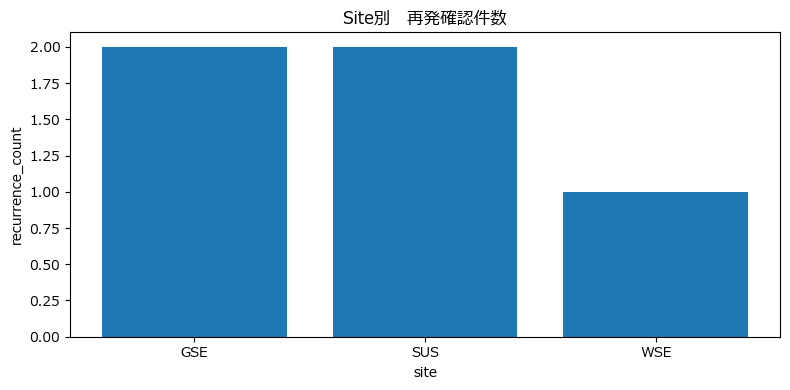

In [43]:
plt.figure(figsize=(8, 4))

plt.bar(
    df_recurrence_summary["site"],
    df_recurrence_summary["recurrence_count"],
)

plt.title("Site別　再発確認件数")
plt.xlabel("site")
plt.ylabel("recurrence_count")

plt.tight_layout()
plt.show()

In [44]:
df_summary["site_category"] = (
    df_summary["site"]
    + "_"
    + df_summary["defect_category"]
)
df_summary

,site,defect_category,defect_total,production_qty,defect_ppm,ppm_rank,risk_level,site_category
0,GSE,CAN通信,3,70000,42.857143,1.0,Low,GSE_CAN通信
1,MELMB,NTF,1,150000,6.666667,1.0,Low,MELMB_NTF
2,MELMB,コイル,1,150000,6.666667,1.0,Low,MELMB_コイル
3,SUS,コイル,3,120000,25.000000,1.0,Low,SUS_コイル
4,SUS,Buck-IC,1,120000,8.333333,2.0,Low,SUS_Buck-IC
5,WSE,コイル,3,90000,33.333333,1.0,Low,WSE_コイル
6,WSE,CAN通信,1,90000,11.111111,2.0,Low,WSE_CAN通信


In [45]:
df_summary_graph = df_summary.sort_values(
    "defect_ppm",
    ascending=False,
).reset_index(drop=True)
df_summary_graph

,site,defect_category,defect_total,production_qty,defect_ppm,ppm_rank,risk_level,site_category
0,GSE,CAN通信,3,70000,42.857143,1.0,Low,GSE_CAN通信
1,WSE,コイル,3,90000,33.333333,1.0,Low,WSE_コイル
2,SUS,コイル,3,120000,25.000000,1.0,Low,SUS_コイル
3,WSE,CAN通信,1,90000,11.111111,2.0,Low,WSE_CAN通信
4,SUS,Buck-IC,1,120000,8.333333,2.0,Low,SUS_Buck-IC
5,MELMB,コイル,1,150000,6.666667,1.0,Low,MELMB_コイル
6,MELMB,NTF,1,150000,6.666667,1.0,Low,MELMB_NTF


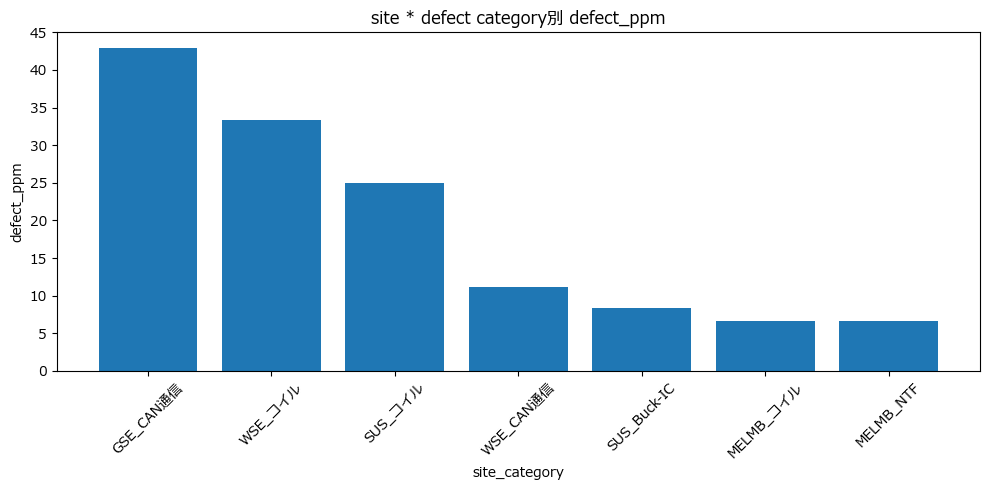

In [53]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_summary_graph["site_category"],
    df_summary_graph["defect_ppm"],
)

plt.title("site * defect category別 defect_ppm")
plt.xlabel("site_category")
plt.ylabel("defect_ppm")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()